In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
df_processed = pd.read_csv('../dataset/student_data_processed.csv')
print(f'Dataset shape: {df_processed.shape}')

X_train_reg, X_test_reg, y_train_reg, y_test_reg = joblib.load('../dataset/train_test_regression.pkl')
X_train_cls, X_test_cls, y_train_cls, y_test_cls = joblib.load('../dataset/train_test_classification.pkl')

preprocessing_objects = joblib.load('../dataset/preprocessing_objects.pkl')
scaler = preprocessing_objects['scaler']

print('Data loaded successfully!')
print(f'Regression: Train={X_train_reg.shape[0]}, Test={X_test_reg.shape[0]}')
print(f'Classification: Train={X_train_cls.shape[0]}, Test={X_test_cls.shape[0]}')

Dataset shape: (10000, 39)
Data loaded successfully!
Regression: Train=8000, Test=2000
Classification: Train=8000, Test=2000


## Regression Models

In [3]:
models_reg = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

print('Regression models initialized!')

Regression models initialized!


In [4]:
results_reg = {}

for name in models_reg:
    print(f'\nTraining {name}...')
    
    model = models_reg[name]
    model.fit(X_train_reg, y_train_reg)
    
    y_pred = model.predict(X_test_reg)
    
    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)
    
    results_reg[name] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}
    print(f'  R2: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}')


Training Linear...
  R2: 0.9739, RMSE: 1.9561, MAE: 1.5549

Training Ridge...
  R2: 0.9739, RMSE: 1.9561, MAE: 1.5549

Training Lasso...
  R2: 0.9671, RMSE: 2.1929, MAE: 1.7435

Training DecisionTree...


  R2: 0.9464, RMSE: 2.8019, MAE: 2.2534

Training RandomForest...


  R2: 0.9728, RMSE: 1.9955, MAE: 1.5823

Training GradientBoosting...


  R2: 0.9740, RMSE: 1.9524, MAE: 1.5569

Training SVR...


  R2: 0.9576, RMSE: 2.4902, MAE: 1.8865

Training KNN...


  R2: 0.9271, RMSE: 3.2667, MAE: 2.6007


In [5]:
comparison_df = pd.DataFrame({
    'Model': list(results_reg.keys()),
    'MSE': [results_reg[m]['MSE'] for m in results_reg],
    'RMSE': [results_reg[m]['RMSE'] for m in results_reg],
    'MAE': [results_reg[m]['MAE'] for m in results_reg],
    'R2': [results_reg[m]['R2'] for m in results_reg]
}).sort_values('R2', ascending=False)

print(comparison_df.to_string(index=False))
print(f'\nBest Model: {comparison_df.iloc[0]["Model"]} (R2={comparison_df.iloc[0]["R2"]:.4f})')

           Model       MSE     RMSE      MAE       R2
GradientBoosting  3.811726 1.952364 1.556904 0.973956
           Ridge  3.826178 1.956062 1.554915 0.973857
          Linear  3.826186 1.956064 1.554909 0.973857
    RandomForest  3.982042 1.995505 1.582347 0.972792
           Lasso  4.808907 2.192922 1.743501 0.967142
             SVR  6.200943 2.490169 1.886509 0.957631
    DecisionTree  7.850645 2.801900 2.253350 0.946359
             KNN 10.671491 3.266725 2.600670 0.927085

Best Model: GradientBoosting (R2=0.9740)


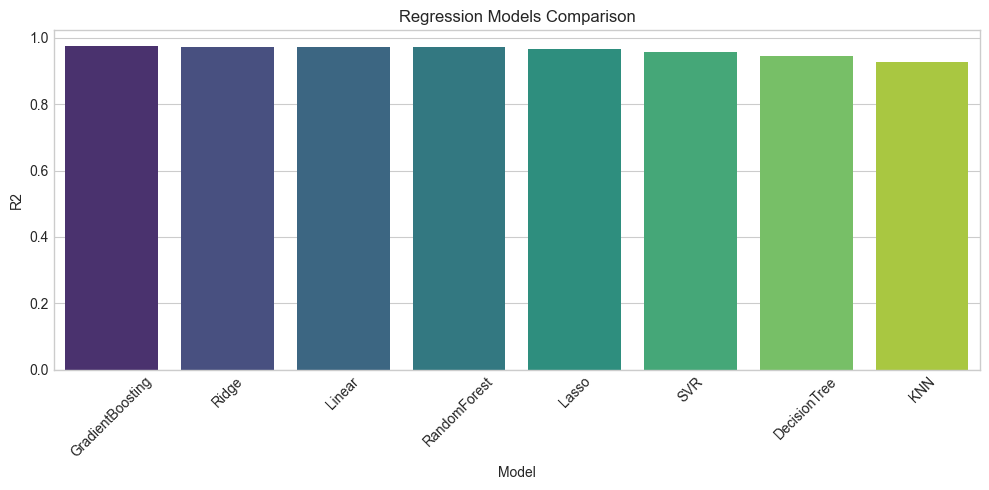

In [6]:
best_model_name = comparison_df.iloc[0]['Model']
best_model_reg = models_reg[best_model_name]

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='Model', y='R2', palette='viridis', hue='Model')
plt.title('Regression Models Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../docs/regression_models_comparison.png', dpi=150)
plt.show()

Top 10 Features:
          Feature  Importance
avg_subject_score    0.975119
     previous_gpa    0.023038
       math_score    0.000274
    reading_score    0.000243
    science_score    0.000191
    writing_score    0.000166
 study_efficiency    0.000120
 engagement_score    0.000117
      sleep_hours    0.000108
  attendance_rate    0.000105


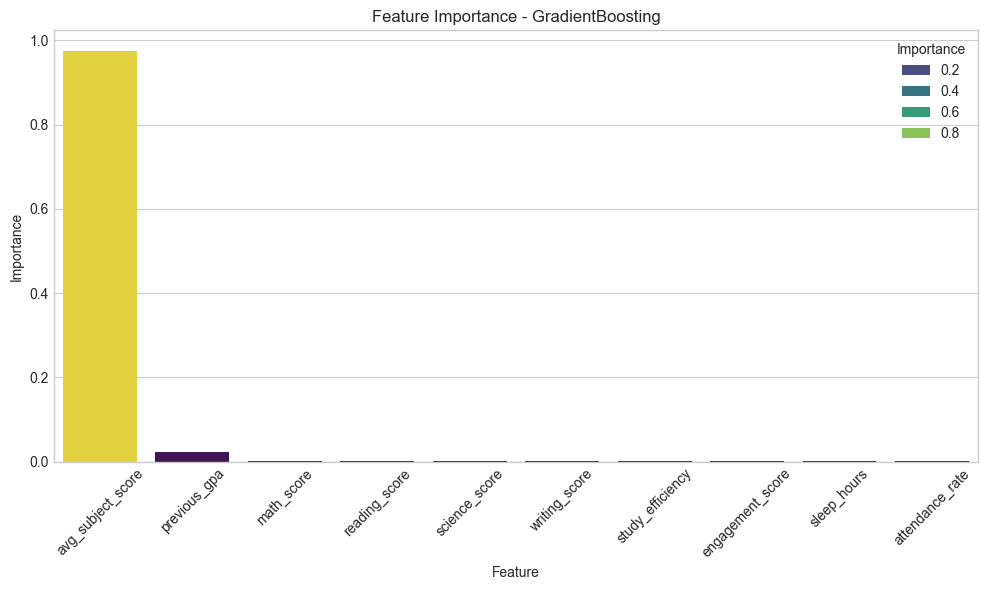

In [7]:
if hasattr(best_model_reg, 'feature_importances_'):
    feat_imp = pd.DataFrame({'Feature': X_train_reg.columns, 'Importance': best_model_reg.feature_importances_})
    feat_imp = feat_imp.sort_values('Importance', ascending=False).head(10)
    print('Top 10 Features:')
    print(feat_imp.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp, x='Feature', y='Importance', palette='viridis', hue='Importance')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../docs/feature_importance.png', dpi=150)
    plt.show()

## Classification Models

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models_cls = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'NaiveBayes': GaussianNB()
}

print('Classification models initialized!')

Classification models initialized!


In [9]:
results_cls = {}

for name in models_cls:
    print(f'\nTraining {name}...')
    
    model = models_cls[name]
    model.fit(X_train_cls, y_train_cls)
    
    y_pred = model.predict(X_test_cls)
    
    acc = accuracy_score(y_test_cls, y_pred)
    prec = precision_score(y_test_cls, y_pred)
    rec = recall_score(y_test_cls, y_pred)
    f1 = f1_score(y_test_cls, y_pred)
    
    results_cls[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'y_pred': y_pred}
    print(f'  Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}')


Training LogisticRegression...
  Accuracy: 0.9470, Precision: 0.9492, Recall: 0.9414, F1: 0.9452

Training DecisionTree...
  Accuracy: 0.9250, Precision: 0.9255, Recall: 0.9198, F1: 0.9226

Training RandomForest...


  Accuracy: 0.9470, Precision: 0.9501, Recall: 0.9403, F1: 0.9452

Training GradientBoosting...


  Accuracy: 0.9495, Precision: 0.9532, Recall: 0.9424, F1: 0.9477

Training SVM...


  Accuracy: 0.9500, Precision: 0.9504, Recall: 0.9465, F1: 0.9485

Training KNN...
  Accuracy: 0.9130, Precision: 0.9122, Recall: 0.9084, F1: 0.9103

Training NaiveBayes...
  Accuracy: 0.9250, Precision: 0.9014, Recall: 0.9496, F1: 0.9248


In [10]:
comparison_cls = pd.DataFrame({
    'Model': list(results_cls.keys()),
    'Accuracy': [results_cls[m]['Accuracy'] for m in results_cls],
    'Precision': [results_cls[m]['Precision'] for m in results_cls],
    'Recall': [results_cls[m]['Recall'] for m in results_cls],
    'F1': [results_cls[m]['F1'] for m in results_cls]
}).sort_values('F1', ascending=False)

print(comparison_cls.to_string(index=False))
print(f'\nBest Model: {comparison_cls.iloc[0]["Model"]} (F1={comparison_cls.iloc[0]["F1"]:.4f})')

             Model  Accuracy  Precision   Recall       F1
               SVM    0.9500   0.950413 0.946502 0.948454
  GradientBoosting    0.9495   0.953174 0.942387 0.947750
LogisticRegression    0.9470   0.949170 0.941358 0.945248
      RandomForest    0.9470   0.950104 0.940329 0.945191
        NaiveBayes    0.9250   0.901367 0.949588 0.924850
      DecisionTree    0.9250   0.925466 0.919753 0.922601
               KNN    0.9130   0.912190 0.908436 0.910309

Best Model: SVM (F1=0.9485)


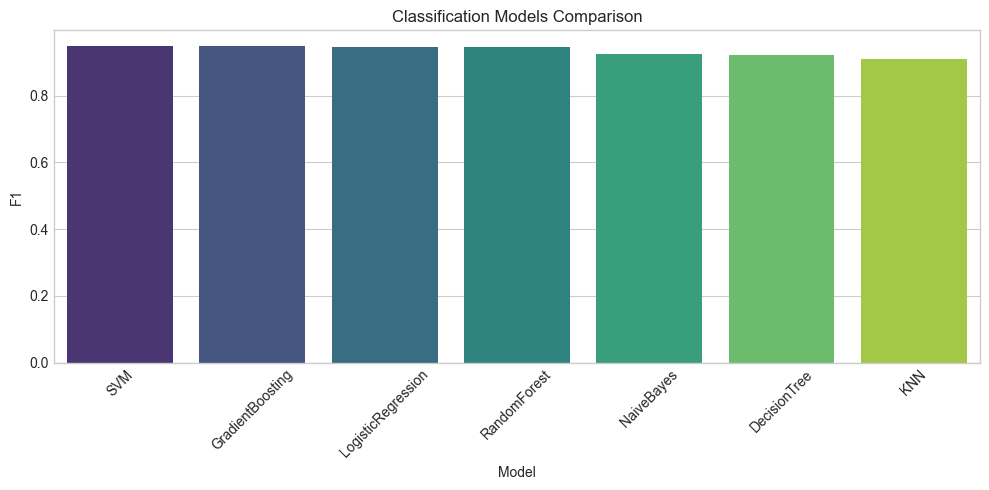

In [11]:
best_cls_name = comparison_cls.iloc[0]['Model']
best_model_cls = models_cls[best_cls_name]

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_cls, x='Model', y='F1', palette='viridis', hue='Model')
plt.title('Classification Models Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../docs/classification_models_comparison.png', dpi=150)
plt.show()

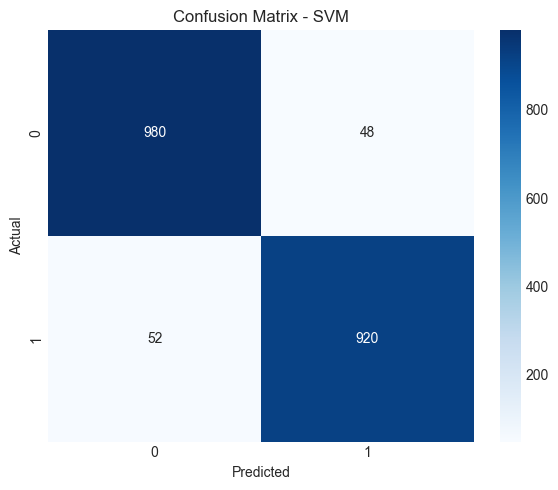

In [12]:
cm = confusion_matrix(y_test_cls, results_cls[best_cls_name]['y_pred'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_cls_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../docs/confusion_matrix.png', dpi=150)
plt.show()

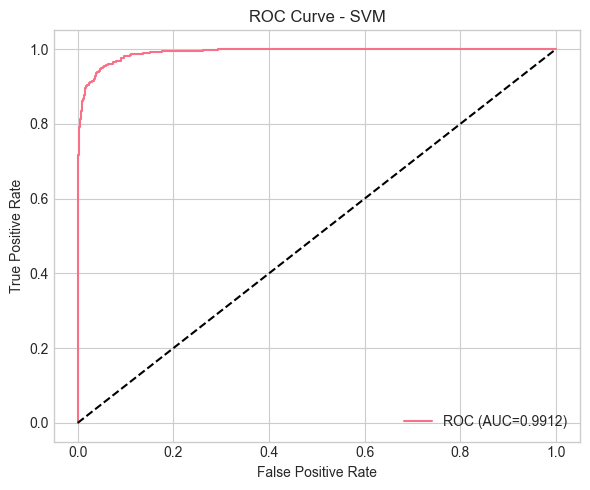

In [13]:
y_proba = best_model_cls.predict_proba(X_test_cls)[:, 1]
fpr, tpr, _ = roc_curve(y_test_cls, y_proba)
auc = roc_auc_score(y_test_cls, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC={auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_cls_name}')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/roc_curve.png', dpi=150)
plt.show()

## Cross-Validation

In [14]:
cv_reg = cross_val_score(best_model_reg, X_train_reg, y_train_reg, cv=5, scoring='r2')
print(f'Regression CV R2: {cv_reg.mean():.4f} (+/- {cv_reg.std():.4f})')

Regression CV R2: 0.9744 (+/- 0.0007)


In [15]:
cv_cls = cross_val_score(best_model_cls, X_train_cls, y_train_cls, cv=5, scoring='f1')
print(f'Classification CV F1: {cv_cls.mean():.4f} (+/- {cv_cls.std():.4f})')

Classification CV F1: 0.9436 (+/- 0.0042)


## Save Models

In [16]:
joblib.dump(best_model_reg, '../dataset/best_regression_model.pkl')
joblib.dump(best_model_cls, '../dataset/best_classification_model.pkl')
print('Models saved successfully!')

Models saved successfully!


## Summary

In [17]:
print('='*60)
print('MODEL BUILDING SUMMARY')
print('='*60)
print(f'\nBest Regression: {best_model_name}')
print(f'  R2: {comparison_df.iloc[0]["R2"]:.4f}')
print(f'  CV R2: {cv_reg.mean():.4f}')
print(f'\nBest Classification: {best_cls_name}')
print(f'  Accuracy: {comparison_cls.iloc[0]["Accuracy"]:.4f}')
print(f'  F1: {comparison_cls.iloc[0]["F1"]:.4f}')
print(f'  CV F1: {cv_cls.mean():.4f}')
print('='*60)

MODEL BUILDING SUMMARY

Best Regression: GradientBoosting
  R2: 0.9740
  CV R2: 0.9744

Best Classification: SVM
  Accuracy: 0.9500
  F1: 0.9485
  CV F1: 0.9436
